<a href="https://colab.research.google.com/github/Rex-Kartik/Machine-Learning/blob/main/gen_ai/image_Captioning_gen_ai_from_scract/Image_reading_model_training_from_scract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Model : {device}")

Model : cpu


In [3]:
transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [4]:
training_dataset = torchvision.datasets.CIFAR10(
    root = "/content/drive/MyDrive/Colab Notebooks/Data",
    train = True,
    download= True,
    transform = transformation
)

In [5]:
testing_dataset = torchvision.datasets.CIFAR10(
    root = "/content/drive/MyDrive/Colab Notebooks/Data",
    train = False,
    download = True,
    transform = transformation
)

In [6]:
training_loader = torch.utils.data.DataLoader(
    training_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 3
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [7]:
testing_loader = torch.utils.data.DataLoader(
    testing_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 2
)

In [8]:
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
images, labels = next(iter(training_loader))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
grid = torchvision.utils.make_grid(images[:8])
grid = grid.permute(1, 2, 0)

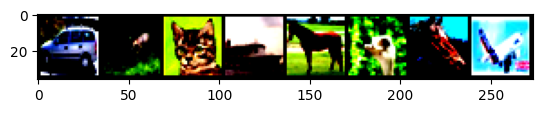

['car', 'deer', 'cat', 'ship', 'horse', 'bird', 'horse', 'plane']


In [11]:
plt.imshow(grid)
plt.show()
print([classes[label.item()] for label in labels[:8]])

In [12]:
class TinyCNN(nn.Module):
  def __init__(self):
    super(TinyCNN, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding = 1)
    self.pool = nn.MaxPool2d(2,2)
    self.fc1 = nn.Linear(2048, 512)
    self.fc2 = nn.Linear(512, 64)
    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [13]:
model = TinyCNN()

In [14]:
dummy_input = torch.randn(4, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

torch.Size([4, 10])


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = 0.001)

In [16]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,175,818


In [17]:
num_epoch = 10

In [18]:
model.to(device)
for epoch in range(num_epoch):
  model.train()
  running_loss = 0.0
  for images, labels in training_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  avg_loss = running_loss / len(training_loader)
  print(f"Epoch {epoch+1}/{num_epoch}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 1.3755
Epoch 2/10, Loss: 0.9067
Epoch 3/10, Loss: 0.7131
Epoch 4/10, Loss: 0.5776
Epoch 5/10, Loss: 0.4555
Epoch 6/10, Loss: 0.3551
Epoch 7/10, Loss: 0.2718
Epoch 8/10, Loss: 0.2058
Epoch 9/10, Loss: 0.1664
Epoch 10/10, Loss: 0.1273


In [19]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in testing_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
  accuracy = correct * 100 / total
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 75.21


In [32]:
def show_filter(layer):
  plt.close
  feature_maps = activation[layer][0].cpu().numpy()

  fig,axes = plt.subplots(4,4, figsize = (8,8))
  plt.suptitle(f"{layer} filters")
  for i, ax in enumerate(axes.flat):
    if i < 16:
      ax.imshow(feature_maps[i], cmap = 'gray')
      ax.set_title(f"Filter {i+1}")
    ax.axis('off')
  plt.tight_layout()
  plt.show()

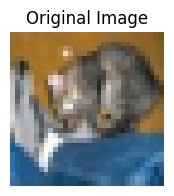

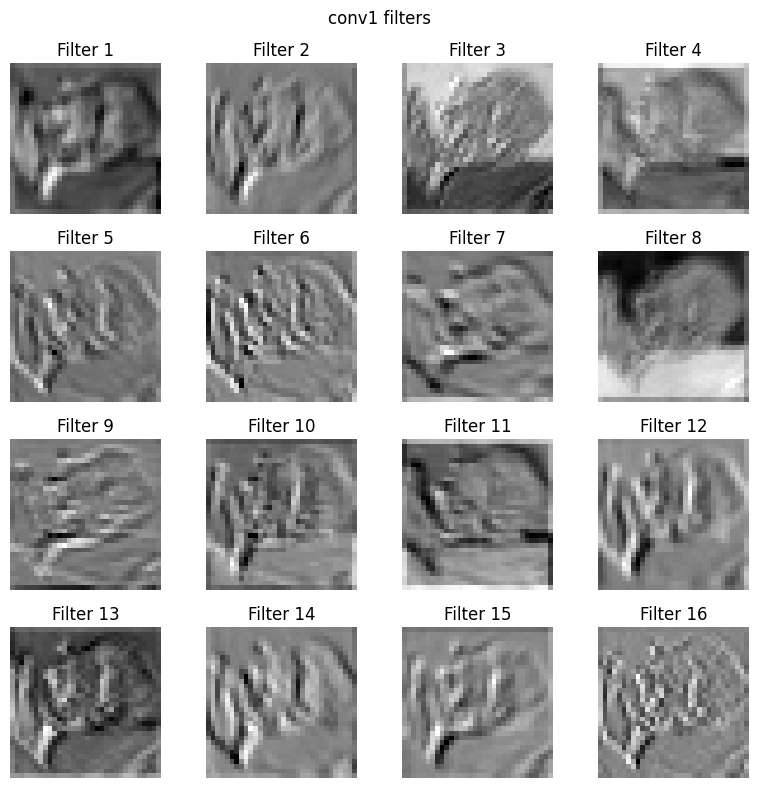

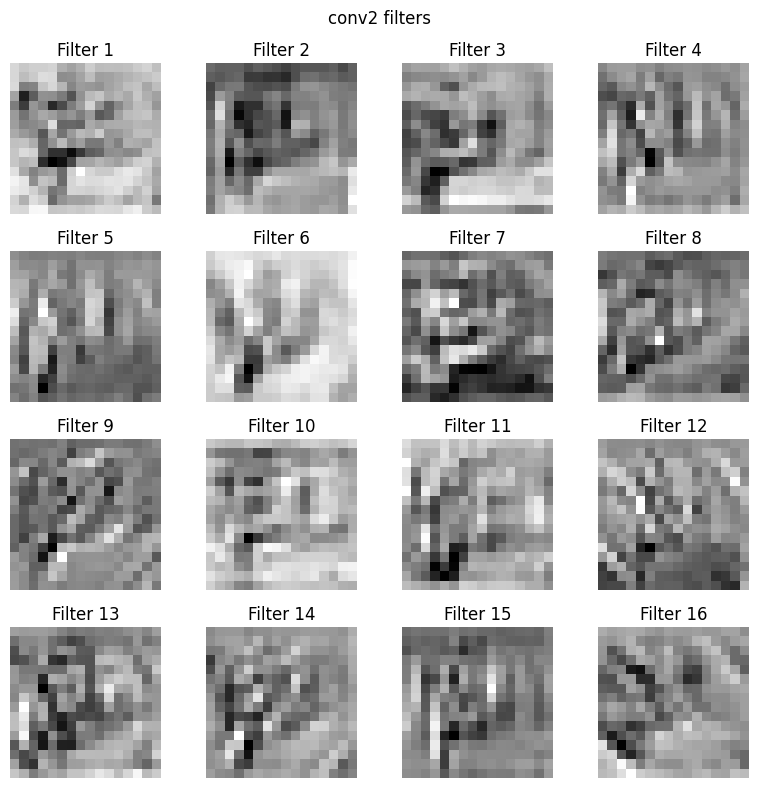

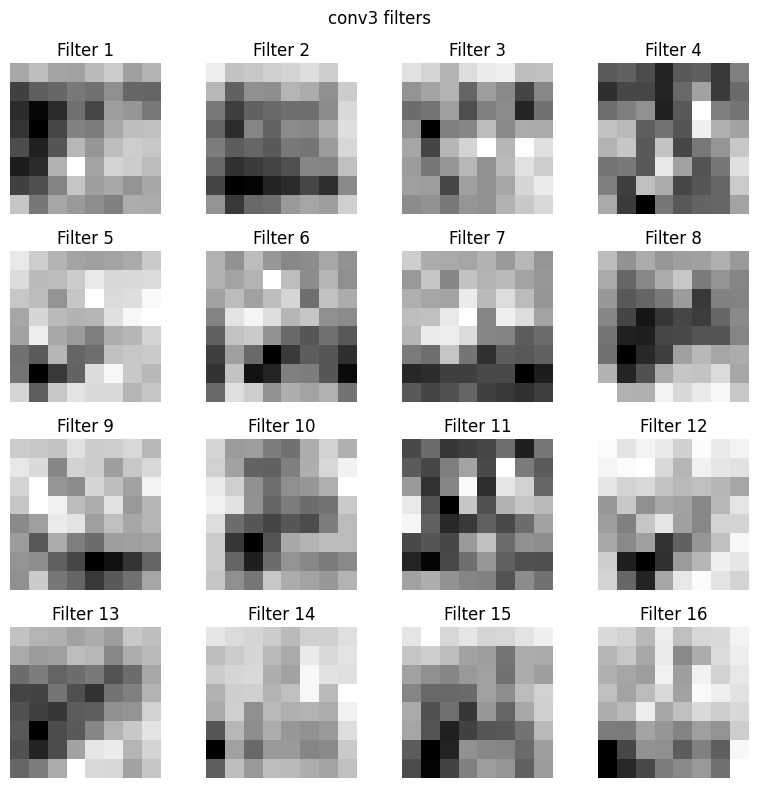

In [33]:
import numpy as np

# Get a single image from the test set
test_images, _ = next(iter(testing_loader))
img = test_images[0:1].to(device)  # shape: [1, 3, 32, 32]

# Register a hook to capture conv1 output
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

model.conv1.register_forward_hook(get_activation('conv1'))
model.conv2.register_forward_hook(get_activation('conv2'))
model.conv3.register_forward_hook(get_activation('conv3'))
_ = model(img)

plt.figure(figsize = (2,2))
plt.title("Original Image")
plt.axis('off')

# Denormalize the image for display
# Retrieve mean and std from the transformation
mean = torch.tensor([0.4914, 0.4822, 0.4465]).to(device)
std = torch.tensor([0.2470, 0.2435, 0.2616]).to(device)
img_denorm = img * std.view(1, 3, 1, 1) + mean.view(1, 3, 1, 1)

# Clamp values to [0, 1] as imshow expects this range for float images
img_display = torch.clamp(img_denorm, 0, 1)

plt.imshow(img_display.cpu().squeeze().permute(1, 2, 0))
plt.show()

# Plot the first 16 feature maps (activations)
show_filter('conv1')
show_filter('conv2')
show_filter('conv3')